In [23]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

In [24]:

df = pd.read_excel("Dataset Project 404.xlsx", sheet_name="original")


In [25]:
features = [
    'Linguistic',
    'Musical',
    'Bodily',
    'Logical - Mathematical',
    'Spatial-Visualization',
    'Interpersonal',
    'Intrapersonal',
    'Naturalist'
]
# Target column (career/job recommendation)
target = 'Job profession'

df = df[features + [target]].copy()
df[target] = df[target].astype(str).str.strip()
df = df.dropna()

In [26]:
# 5. Prepare X and y
X = df[features].values
y = df[target].values

In [27]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convert target into one-hot encoding
y_categorical = to_categorical(y_encoded)


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)


In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(y_categorical.shape[1], activation='softmax')
])

In [31]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1354 - loss: 3.8764 - val_accuracy: 0.4340 - val_loss: 2.9426
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4353 - loss: 2.1858 - val_accuracy: 0.7951 - val_loss: 1.1545
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6228 - loss: 1.2405 - val_accuracy: 0.8472 - val_loss: 0.6780
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6892 - loss: 0.9365 - val_accuracy: 0.8368 - val_loss: 0.5366
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7391 - loss: 0.7793 - val_accuracy: 0.8958 - val_loss: 0.4159
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7522 - loss: 0.6876 - val_accuracy: 0.8750 - val_loss: 0.3890
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7795 - loss: 0.6297 - val_accuracy: 0.8767 - val_loss: 0.3524
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7852 - loss: 0.6012 - val_accuracy: 0.

In [33]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


Test Loss: 0.22069679200649261
Test Accuracy: 0.9013888835906982


In [34]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [35]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\nClassification Metrics:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)


Classification Metrics:
Accuracy : 0.9013888888888889
Precision: 0.9022994366744368
Recall   : 0.9013888888888889
F1-Score : 0.8954525129593555


In [36]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))



Classification Report:

                                                                                                precision    recall  f1-score   support

                                                                               Actor / Actress       0.77      1.00      0.87        10
                                                                                       Actuary       0.83      1.00      0.91        10
                                                                                Anthropologist       1.00      1.00      1.00        10
                                                                                  Archeologist       1.00      1.00      1.00        10
                                                                                        Artist       1.00      1.00      1.00        10
                                                                                    Astronomer       0.91      1.00      0.95        10
                      

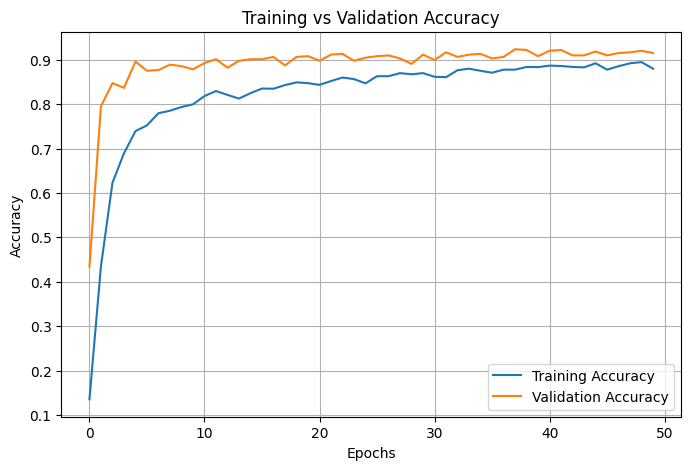

In [37]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

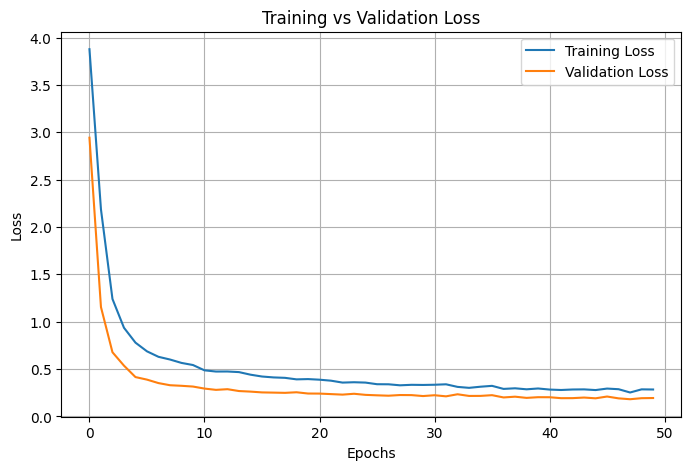

In [38]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
# 18. Predict career for a new student
sample_student = np.array([[15, 8, 12, 18, 16, 14, 17, 10]])
# Example order:
# Linguistic, Musical, Bodily, Logical-Mathematical, Spatial-Visualization,
# Interpersonal, Intrapersonal, Naturalist

sample_student_scaled = scaler.transform(sample_student)
sample_pred = model.predict(sample_student_scaled)
predicted_class = np.argmax(sample_pred, axis=1)[0]
predicted_job = label_encoder.inverse_transform([predicted_class])[0]

print("\nRecommended Career Path for sample student:", predicted_job)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

Recommended Career Path for sample student: Engineer
